In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
import statsmodels.api as sm
from scipy.stats import norm

# Configurações para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [2]:
# Carregando os dados originais
data = pd.read_csv("./data_updated.csv")
data["week"] = pd.to_datetime(data["week"])
data.set_index("week", inplace=True)

data["inv"] = data["inv"].shift(1)
data["users"] = data["users"].shift(1)

data["inv_lag_2"] = data["inv"].shift(1)
data["users_lag_2"] = data["users"].shift(1)

data["inv_lag_4"] = data["inv"].shift(3)
data["users_lag_4"] = data["users"].shift(3)

data["vol_lag_1"] = data["volume"].shift(1)

data["trend"] = np.arange(len(data))

data.dropna(inplace=True)

In [3]:
data.head()

,volume,inv,users,inv_lag_2,users_lag_2,inv_lag_4,users_lag_4,vol_lag_1,trend
week,,,,,,,,,
2022-11-28,1.23,5.623875,24.238,2.297810,5.875,1.609882,6.500,1.69,4
2022-12-05,0.77,1.473418,7.648,5.623875,24.238,1.880548,7.061,1.23,5
2022-12-12,0.49,0.691911,4.105,1.473418,7.648,2.297810,5.875,0.77,6
2022-12-19,0.14,0.335866,2.060,0.691911,4.105,5.623875,24.238,0.49,7
2022-12-26,0.39,0.182806,0.655,0.335866,2.060,1.473418,7.648,0.14,8


In [4]:
# Função para o Winkler Score
def winkler_score(y_true, lower, upper, alpha):
    score = np.where(
        y_true < lower,
        (upper - lower) + (2 / alpha) * (lower - y_true),
        np.where(
            y_true > upper,
            (upper - lower) + (2 / alpha) * (y_true - upper),
            (upper - lower),
        ),
    )
    return np.mean(score)


# Função para o Erro de Quantil
def quantile_score(y_true, quantile_forecast, p):
    error = y_true - quantile_forecast
    return np.mean(np.where(error >= 0, p * error, (p - 1) * error))


# Função para o CRPS de uma distribuição Normal
def crps_gaussian(y_true, mu, sigma):
    z = (y_true - mu) / sigma
    crps = sigma * (
        z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi)
    )
    return np.mean(crps)

In [5]:
def get_metrics(y_true, y_pred, alpha=0.05, m=12):
    residuals = y_true - y_pred
    residuals_std = np.std(residuals)
    
    z_score = norm.ppf(1 - alpha / 2)
    lower = y_pred - z_score * residuals_std
    upper = y_pred + z_score * residuals_std

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    mase_scale = np.mean(np.abs(pd.Series(y_true).diff(m).dropna()))
    mase = mae / mase_scale if mase_scale != 0 else np.nan

    winkler = winkler_score(y_true, lower, upper, alpha)
    sigma_h = pd.Series(residuals_std, index=pd.Series(y_true).index)
    crps = crps_gaussian(y_true, y_pred, sigma_h)

    quantiles_to_check = [0.1, 0.25, 0.5, 0.75, 0.9]
    avg_quantile_loss = []
    for p in quantiles_to_check:
        quantile_forecast = norm.ppf(p, loc=y_pred, scale=sigma_h)
        avg_quantile_loss.append(quantile_score(y_true, quantile_forecast, p))

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape * 100,
        'MASE': mase,
        'Winkler Score': winkler,
        'Avg Quantile Score': np.mean(avg_quantile_loss),
        'CRPS': crps,
    }

In [6]:
X = data.drop('volume', axis=1)
y = data['volume']

In [7]:
train_size_full = len(data)
train_size_adjusted = int(train_size_full * 0.8) - 12

X_train, X_test = X.iloc[:train_size_adjusted], X.iloc[train_size_adjusted:]
y_train, y_test = y.iloc[:train_size_adjusted], y.iloc[train_size_adjusted:]

In [8]:
predictions = {}
models = {}

months_cols = [col for col in data.columns if 'mes_' in col]

models_cols = { 
    "Baseline": ["trend", "inv", "users"],
    "Lags": ["inv", "users", "trend", "inv_lag_2", "users_lag_2", "inv_lag_4", "users_lag_4"],
}

for model_name, cols in models_cols.items():
    X_train_model = sm.add_constant(X_train[cols])
    X_test_model = sm.add_constant(X_test[cols])

    model = sm.OLS(y_train, X_train_model).fit()
    models[model_name] = model

    y_pred = model.predict(X_test_model)
    predictions[model_name] = y_pred

In [9]:
results = {}

for model_name, y_pred in predictions.items():

    metrics = get_metrics(y_test, y_pred)
    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='RMSE'))

,RMSE,MAE,MAPE (%),MASE,Winkler Score,Avg Quantile Score,CRPS
Baseline,6.420716,4.843685,35.776844,1.086893,46.093686,1.799324,3.621136
Lags,6.474763,4.946441,37.052877,1.109950,46.955585,1.822903,3.672507


In [10]:
models["Baseline"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     141.7
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           6.08e-37
Time:                        23:07:12   Log-Likelihood:                -164.32
No. Observations:                 110   AIC:                             336.6
Df Residuals:                     106   BIC:                             347.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3360      0.235     -5.679      0.000      -1.802      -0.870
trend          0.0488      0.004     13.055      0.000       0.041       0.056
inv            0.6782      0.256      2.651      0.009       0.171       1.185
users          0.0853      0.037      2.326      0.022       0.013       0.158
==============================================================================
Omnibus:                        6.582   Durbin-Watson:                   0.635
Prob(Omnibus):                  0.037   Jarque-Bera (JB):                8.021
Skew:                           0.317   Prob(JB):                       0.0181
Kurtosis:                       4.161   Cond. No.                         183.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
models["Lags"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     90.61
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           7.01e-41
Time:                        23:07:12   Log-Likelihood:                -144.22
No. Observations:                 110   AIC:                             304.4
Df Residuals:                     102   BIC:                             326.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.5046      0.215     -7.006      0.000      -1.931      -1.079
inv             0.3974      0.288      1.378      0.171      -0.174       0.969
users           0.0377      0.049      0.776      0.439      -0.059       0.134
trend           0.0477      0.003     13.787      0.000       0.041       0.055
inv_lag_2       0.6185      0.287      2.155      0.033       0.049       1.188
users_lag_2    -0.0590      0.050     -1.190      0.237      -0.157       0.039
inv_lag_4      -0.0812      0.231     -0.351      0.726      -0.540       0.377
users_lag_4     0.1122      0.037      2.994      0.003       0.038       0.186
==============================================================================
Omnibus:                        9.468   Durbin-Watson:                   0.755
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               12.814
Skew:                           0.433   Prob(JB):                      0.00165
Kurtosis:                       4.430   Cond. No.                         280.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
models_cols = {
    "Lags": [
        "trend",
        "inv_lag_2",
        "users_lag_4",
    ],
}

for model_name, cols in models_cols.items():
    X_train_model = sm.add_constant(X_train[cols])
    X_test_model = sm.add_constant(X_test[cols])

    model = sm.OLS(y_train, X_train_model).fit()
    models[model_name] = model

    y_pred = model.predict(X_test_model)
    predictions[model_name] = y_pred

In [13]:
models["Lags"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     176.2
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           4.87e-41
Time:                        23:07:12   Log-Likelihood:                -154.51
No. Observations:                 110   AIC:                             317.0
Df Residuals:                     106   BIC:                             327.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4079      0.210     -6.717      0.000      -1.823      -0.992
trend           0.0467      0.003     14.665      0.000       0.040       0.053
inv_lag_2       0.6781      0.117      5.777      0.000       0.445       0.911
users_lag_4     0.1140      0.017      6.620      0.000       0.080       0.148
==============================================================================
Omnibus:                        8.940   Durbin-Watson:                   0.859
Prob(Omnibus):                  0.011   Jarque-Bera (JB):               12.754
Skew:                           0.379   Prob(JB):                      0.00170
Kurtosis:                       4.486   Cond. No.                         148.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
results = {}

for model_name, y_pred in predictions.items():

    metrics = get_metrics(y_test, y_pred)
    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='RMSE'))

,RMSE,MAE,MAPE (%),MASE,Winkler Score,Avg Quantile Score,CRPS
Baseline,6.420716,4.843685,35.776844,1.086893,46.093686,1.799324,3.621136
Lags,6.534769,4.966430,37.091655,1.114436,47.187810,1.834581,3.692731


In [15]:
y_log = np.log(y)

y_log_train, y_log_test = y_log.iloc[:train_size_adjusted], y_log.iloc[train_size_adjusted:]

In [16]:
log_models = {}

models_cols = {
    "Baseline": ["trend", "inv", "users"],
    "Lags": [
        "inv",
        "users",
        "trend",
        "inv_lag_2",
        "users_lag_2",
        "inv_lag_4",
        "users_lag_4",
    ],
}

for model_name, cols in models_cols.items():
    X_train_model = sm.add_constant(X_train[cols])
    X_test_model = sm.add_constant(X_test[cols])

    model = sm.OLS(y_log_train, X_train_model).fit()
    log_models[model_name] = model

    y_log_pred = model.predict(X_test_model)
    y_pred_exp = np.exp(y_log_pred)
    predictions[model_name + " (log)"] = y_pred_exp

In [17]:
results_logs = {}

for model_name, y_pred in predictions.items():
    if "log" not in model_name:
        continue

    metrics = get_metrics(y_test, y_pred)
    results_logs[model_name] = metrics

results_logs_df = pd.DataFrame(results_logs).T
display(results_logs_df.sort_values(by='RMSE'))

,RMSE,MAE,MAPE (%),MASE,Winkler Score,Avg Quantile Score,CRPS
Baseline (log),2.883628,2.306943,20.741983,0.517664,14.088330,0.798054,1.623734
Lags (log),3.116956,2.318995,19.993122,0.520368,16.152304,0.858329,1.719931


In [18]:
log_models["Baseline"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     268.5
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           2.32e-49
Time:                        23:07:12   Log-Likelihood:                -43.687
No. Observations:                 110   AIC:                             95.37
Df Residuals:                     106   BIC:                             106.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4497      0.079    -18.451      0.000      -1.606      -1.294
trend          0.0251      0.001     20.146      0.000       0.023       0.028
inv            0.2101      0.085      2.459      0.016       0.041       0.380
users          0.0364      0.012      2.974      0.004       0.012       0.061
==============================================================================
Omnibus:                        9.210   Durbin-Watson:                   0.765
Prob(Omnibus):                  0.010   Jarque-Bera (JB):                4.003
Skew:                          -0.187   Prob(JB):                        0.135
Kurtosis:                       2.143   Cond. No.                         183.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
log_models["Lags"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     140.3
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           2.14e-49
Time:                        23:07:12   Log-Likelihood:                -32.038
No. Observations:                 110   AIC:                             80.08
Df Residuals:                     102   BIC:                             101.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4506      0.077    -18.728      0.000      -1.604      -1.297
inv             0.1759      0.104      1.692      0.094      -0.030       0.382
users           0.0137      0.017      0.780      0.437      -0.021       0.048
trend           0.0242      0.001     19.419      0.000       0.022       0.027
inv_lag_2       0.2016      0.103      1.948      0.054      -0.004       0.407
users_lag_2    -0.0099      0.018     -0.556      0.579      -0.045       0.026
inv_lag_4      -0.1806      0.083     -2.166      0.033      -0.346      -0.015
users_lag_4     0.0438      0.014      3.244      0.002       0.017       0.071
==============================================================================
Omnibus:                        1.977   Durbin-Watson:                   0.733
Prob(Omnibus):                  0.372   Jarque-Bera (JB):                2.000
Skew:                          -0.278   Prob(JB):                        0.368
Kurtosis:                       2.644   Cond. No.                         280.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
models_cols = {
    "Lags": [
        "trend",
        "inv_lag_2",
        "inv_lag_4",
        "users_lag_4",
    ],
}

for model_name, cols in models_cols.items():
    X_train_model = sm.add_constant(X_train[cols])
    X_test_model = sm.add_constant(X_test[cols])

    model = sm.OLS(y_log_train, X_train_model).fit()
    log_models[model_name] = model

    y_log_pred = model.predict(X_test_model)
    y_pred_exp = np.exp(y_log_pred)
    predictions[model_name + " (log)"] = y_pred_exp

In [21]:
log_models["Lags"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     195.9
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           9.60e-48
Time:                        23:07:12   Log-Likelihood:                -44.571
No. Observations:                 110   AIC:                             99.14
Df Residuals:                     105   BIC:                             112.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4060      0.084    -16.763      0.000      -1.572      -1.240
trend           0.0238      0.001     17.941      0.000       0.021       0.026
inv_lag_2       0.3094      0.044      7.016      0.000       0.222       0.397
inv_lag_4      -0.2178      0.084     -2.585      0.011      -0.385      -0.051
users_lag_4     0.0565      0.012      4.565      0.000       0.032       0.081
==============================================================================
Omnibus:                        1.375   Durbin-Watson:                   0.931
Prob(Omnibus):                  0.503   Jarque-Bera (JB):                1.452
Skew:                          -0.233   Prob(JB):                        0.484
Kurtosis:                       2.685   Cond. No.                         187.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
results_logs = {}

for model_name, y_pred in predictions.items():
    if "log" not in model_name:
        continue

    metrics = get_metrics(y_test, y_pred)
    results_logs[model_name] = metrics

results_logs_df = pd.DataFrame(results_logs).T
display(results_logs_df.sort_values(by='RMSE'))

,RMSE,MAE,MAPE (%),MASE,Winkler Score,Avg Quantile Score,CRPS
Baseline (log),2.883628,2.306943,20.741983,0.517664,14.088330,0.798054,1.623734
Lags (log),3.530138,2.500619,21.542475,0.561123,18.180224,0.972623,1.933805


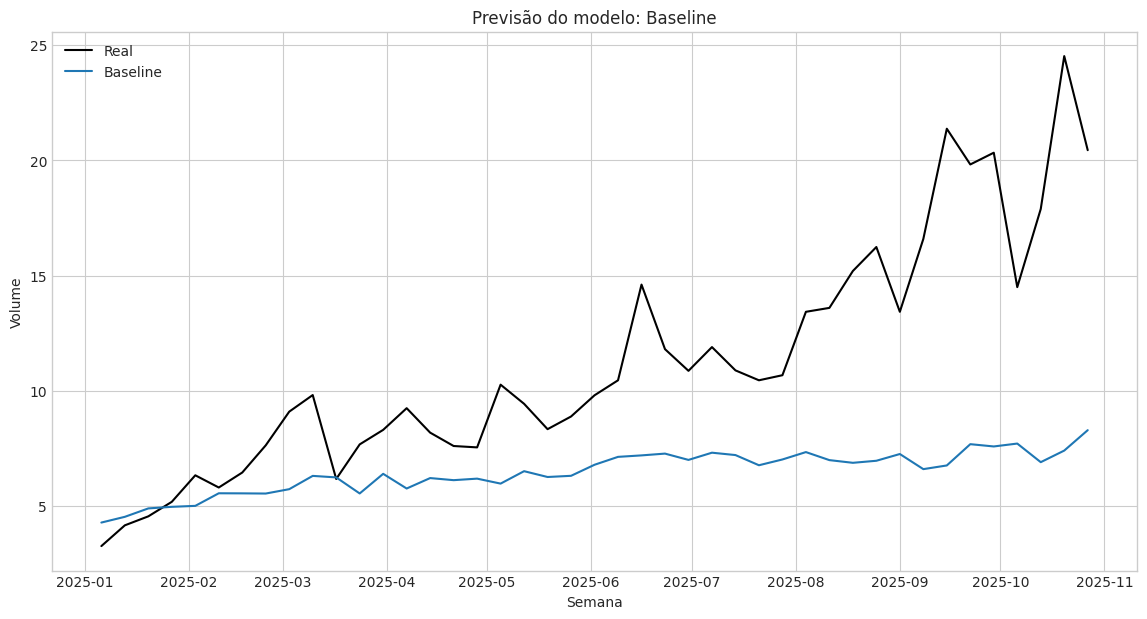

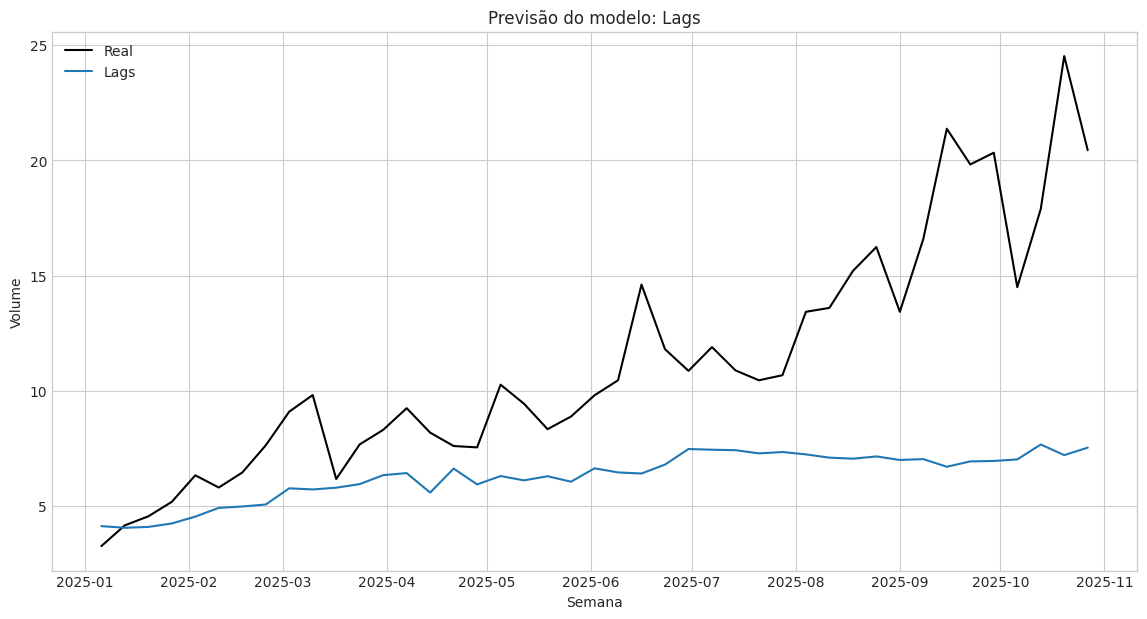

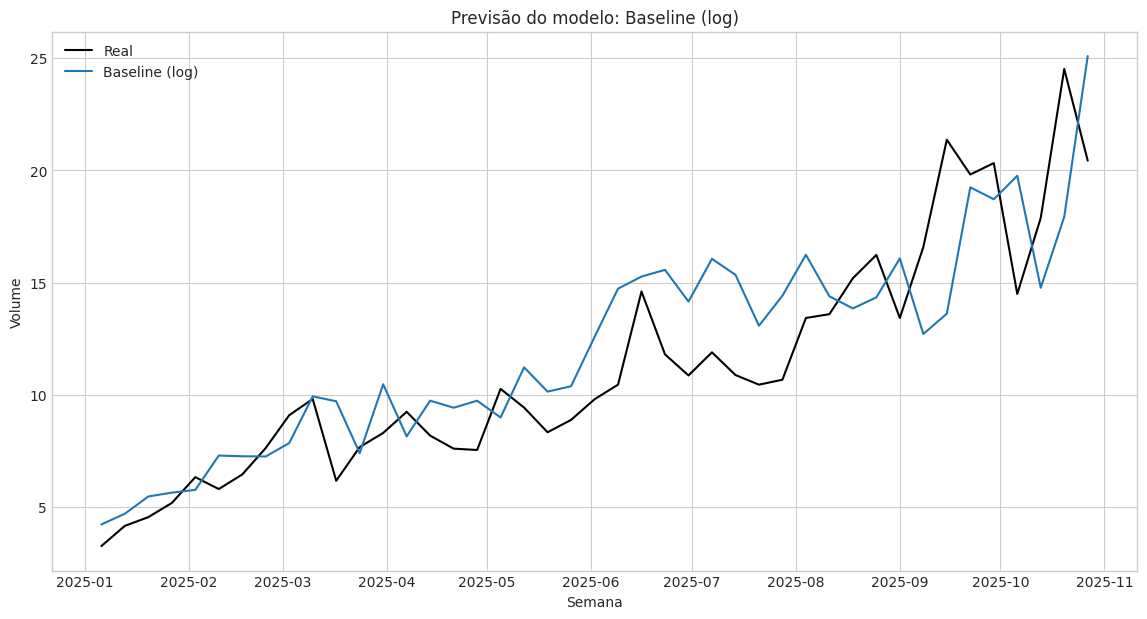

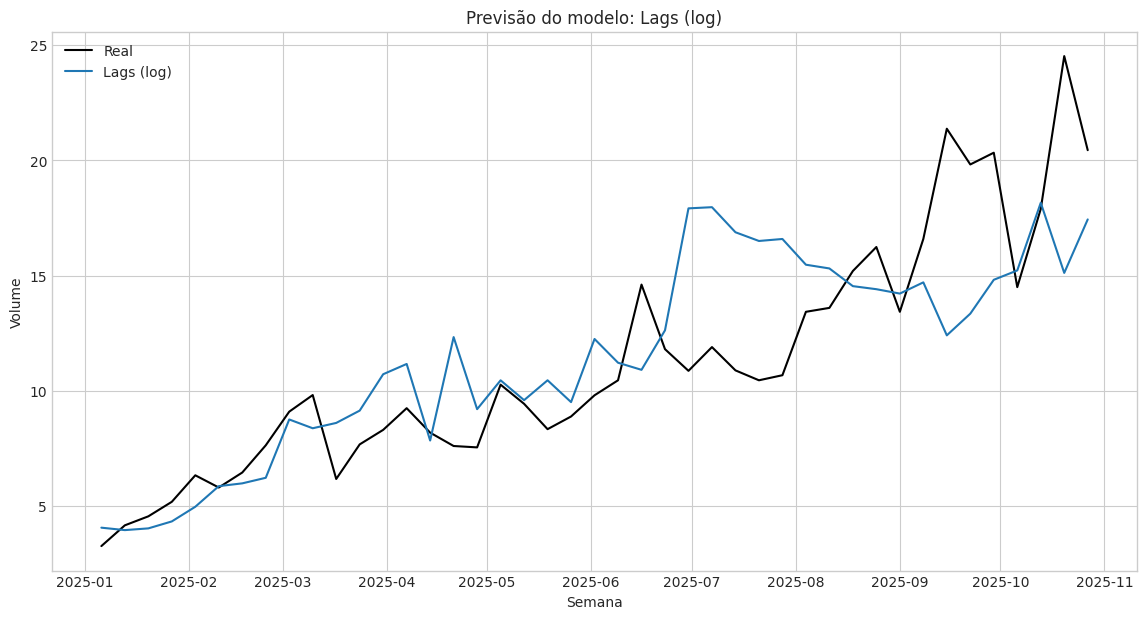

In [23]:
for pred in predictions:
    plt.plot(y_test.index, y_test, label='Real', color='black')
    plt.plot(y_test.index, predictions[pred], label=pred)
    plt.title(f'Previsão do modelo: {pred}')
    plt.xlabel('Semana')
    plt.ylabel('Volume')
    plt.legend()
    plt.show()